In [ ]:
!unzip PartB_DFU_Dataset.zip -d ./Dataset

In [1]:
import torchvision
print(f"Success! Torchvision version: {torchvision.__version__}")

Success! Torchvision version: 0.20.1+cu121


In [2]:
# ── Cell 1 : Imports & paths ─────────────────────────────────────────────────
import os
import random
import csv
import shutil
from pathlib import Path

import pandas as pd
from PIL import Image, ImageOps
import torchvision.transforms.functional as TF
import torch
from torchvision import transforms
from tqdm.notebook import tqdm

# ── CONFIGURE THESE TWO PATHS ────────────────────────────────────────────────
DATASET_DIR = Path("DFUC-2021/DFUC2021_train")         # folder that contains train.csv AND the images/
IMAGE_SUBDIR = "images"          # sub-folder name that holds the .jpg files
CSV_NAME     = "train.csv"       # name of the label file
# ─────────────────────────────────────────────────────────────────────────────

CSV_PATH   = DATASET_DIR / CSV_NAME
IMG_DIR    = DATASET_DIR / IMAGE_SUBDIR

print(f"CSV  : {CSV_PATH.resolve()}")
print(f"Images folder: {IMG_DIR.resolve()}")
assert CSV_PATH.exists(),  "train.csv not found — check DATASET_DIR"
assert IMG_DIR.exists(),   "images folder not found — check IMAGE_SUBDIR"

CSV  : /home/mohid/Dr.SAMABIA/DFUC-2021/DFUC2021_train/train.csv
Images folder: /home/mohid/Dr.SAMABIA/DFUC-2021/DFUC2021_train/images


In [3]:
df = pd.read_csv(CSV_PATH)
print("Columns :", df.columns.tolist())
print("\nClass counts (original):")
print(f"  none      : {df['none'].sum()}")
print(f"  infection : {df['infection'].sum()}")
print(f"  ischaemia : {df['ischaemia'].sum()}")
print(f"  both      : {df['both'].sum()}")

Columns : ['image', 'none', 'infection', 'ischaemia', 'both']

Class counts (original):
  none      : 3572.0
  infection : 3577.0
  ischaemia : 1135.0
  both      : 3105.0


In [4]:
# ── Cell 3 : Augmentation helpers ────────────────────────────────────────────

# --- individual transform functions -------------------------------------------

def aug_equalize(img: Image.Image) -> Image.Image:
    """Histogram equalisation."""
    return ImageOps.equalize(img.convert("RGB"))


def aug_hflip(img: Image.Image) -> Image.Image:
    """Horizontal flip."""
    return TF.hflip(img)


def aug_vflip(img: Image.Image) -> Image.Image:
    """Vertical flip."""
    return TF.vflip(img)


def aug_crop(img: Image.Image, max_crop_frac: float = 0.07) -> Image.Image:
    """
    Blacks out a random square near the center of the image.

    The square size is randomly selected between 2% and
    max_crop_frac of the image dimension.
    """

    img = img.copy()

    w, h = img.size

    # Use smaller dimension so square always fits
    base_dim = min(w, h)

    # Random square size
    frac = random.uniform(0.02, max_crop_frac)
    square_size = max(1, int(base_dim * frac))

    # Center of image
    cx, cy = w // 2, h // 2

    # Small random offset around center
    offset_x = random.randint(-w // 20, w // 20)
    offset_y = random.randint(-h // 20, h // 20)

    cx += offset_x
    cy += offset_y

    # Square coordinates
    x1 = max(0, cx - square_size // 2)
    y1 = max(0, cy - square_size // 2)
    x2 = min(w, x1 + square_size)
    y2 = min(h, y1 + square_size)

    # Black out the square
    pixels = img.load()

    for y in range(y1, y2):
        for x in range(x1, x2):
            pixels[x, y] = (0, 0, 0)

    return img


# Map: suffix → function  (color-jitter and zoom removed; crop added)
AUGMENTATIONS = {
    "e": aug_equalize,
    "h": aug_hflip,
    "v": aug_vflip,
    "k": aug_crop,          # 'k' for crop (c was colour-jitter)
}

print("Augmentation pipeline defined:")
for key, fn in AUGMENTATIONS.items():
    print(f"  [{key}] {fn.__name__}")


Augmentation pipeline defined:
  [e] aug_equalize
  [h] aug_hflip
  [v] aug_vflip
  [k] aug_crop


In [6]:
# ── Cell 4 : Run augmentation & update CSV in real-time ──────────────────────
# ─ Minority classes  (ischaemia, both)  → ALL augmentations applied to EVERY image
# ─ Majority classes  (none, infection)  → ALL augmentations applied to a RANDOM
#   10 % sample, so the total image count stays ≤ original × 1.4  (≈ original + 40%)
#   For infection : 2 555 original  →  max 3 577 total  (capped)
# ─────────────────────────────────────────────────────────────────────────────────

import random

# ── 1. Minority classes ───────────────────────────────────────────────────────
minority_mask = (df["ischaemia"] == 1) | (df["both"] == 1)
minority_df   = df[minority_mask].copy()
print(f"Minority images to augment : {len(minority_df)}  "
      f"(ischaemia={df['ischaemia'].sum()}, both={df['both'].sum()})")

new_rows_added = 0
skipped        = 0

with open(CSV_PATH, "a", newline="") as csv_file:
    writer = csv.writer(csv_file)

    for _, row in tqdm(minority_df.iterrows(),
                       total=len(minority_df),
                       desc="Augmenting minority"):

        src_name = row["image"]
        src_path = IMG_DIR / src_name

        if not src_path.exists():
            print(f"  [SKIP] {src_name} not found in {IMG_DIR}")
            skipped += 1
            continue

        label_none      = int(row["none"])
        label_infection = int(row["infection"])
        label_ischaemia = int(row["ischaemia"])
        label_both      = int(row["both"])

        stem = Path(src_name).stem
        ext  = Path(src_name).suffix
        orig_img = Image.open(src_path).convert("RGB")

        for suffix, aug_fn in AUGMENTATIONS.items():
            new_name = f"{stem}{suffix}{ext}"
            new_path = IMG_DIR / new_name
            if new_path.exists():
                continue
            aug_img = aug_fn(orig_img)
            aug_img.save(new_path, quality=95)
            writer.writerow([new_name, label_none, label_infection,
                             label_ischaemia, label_both])
            csv_file.flush()
            new_rows_added += 1

print(f"\n✅ Minority done — {new_rows_added} new images.")
print(f"   Skipped (file missing): {skipped}")

# ── 2. Majority classes  (none & infection) ───────────────────────────────────
#  For each majority image, there is a 1-in-10 (10%) random chance it is
#  selected for augmentation.  When selected, ALL augmentations are applied
#  (one new image per augmentation).  A hard cap prevents exceeding the
#  target ceiling for each class.

# Per-class caps: ceil ≈ original_count * 1.4  (keeps total ≤ 3577 for infection)
MAJORITY_SELECTION_PROB = 0.10   # 10 % chance each image is chosen

# Caps expressed as maximum NEW images per class (original count not re-counted)
# infection: 2555 original → 3577 cap → 1022 new max
# none: same ratio (original × 0.4) — computed dynamically below
CAP_RATIO = 1022 / 2555          # ≈ 0.40  — same growth ratio for both classes

majority_classes = {
    'infection': df[df['infection'] == 1].copy(),
    'none':      df[df['none']      == 1].copy(),
}

maj_rows_added = 0
maj_skipped    = 0

with open(CSV_PATH, "a", newline="") as csv_file:
    writer = csv.writer(csv_file)

    for class_name, class_df in majority_classes.items():
        orig_count  = len(class_df)
        max_new     = int(orig_count * CAP_RATIO)   # max new images for this class
        class_added = 0

        print(f"\n{class_name}: {orig_count} original images  "
              f"→ max {max_new} new augmented  "
              f"(cap total = {orig_count + max_new})")

        for _, row in tqdm(class_df.iterrows(),
                           total=len(class_df),
                           desc=f"Augmenting {class_name}"):

            # Hard-cap check before even loading the image
            if class_added >= max_new:
                break

            # Random 10 % selection
            if random.random() > MAJORITY_SELECTION_PROB:
                continue

            src_name = row["image"]
            src_path = IMG_DIR / src_name

            if not src_path.exists():
                maj_skipped += 1
                continue

            label_none      = int(row["none"])
            label_infection = int(row["infection"])
            label_ischaemia = int(row["ischaemia"])
            label_both      = int(row["both"])

            stem     = Path(src_name).stem
            ext      = Path(src_name).suffix
            orig_img = Image.open(src_path).convert("RGB")

            for suffix, aug_fn in AUGMENTATIONS.items():
                if class_added >= max_new:
                    break

                new_name = f"{stem}_maj{suffix}{ext}"   # _maj prefix avoids name clash
                new_path = IMG_DIR / new_name

                if new_path.exists():
                    continue

                aug_img = aug_fn(orig_img)
                aug_img.save(new_path, quality=95)
                writer.writerow([new_name, label_none, label_infection,
                                 label_ischaemia, label_both])
                csv_file.flush()
                class_added   += 1
                maj_rows_added += 1

        print(f"  → {class_added} new images added for {class_name}  "
              f"(total now ≈ {orig_count + class_added})")

print(f"\n✅ Majority done — {maj_rows_added} new images.")
print(f"   Skipped (file missing): {maj_skipped}")
print(f"\nGrand total new images : {new_rows_added + maj_rows_added}")


Minority images to augment : 4240  (ischaemia=1135.0, both=3105.0)


In [4]:
# ── Cell 5 : Verify final CSV ─────────────────────────────────────────────────
df_final = pd.read_csv(CSV_PATH)
print("Class counts (after augmentation):")
print(f"  none      : {df_final['none'].sum()}")
print(f"  infection : {df_final['infection'].sum()}")
print(f"  ischaemia : {df_final['ischaemia'].sum()}")
print(f"  both      : {df_final['both'].sum()}")
print("\nLast 10 rows (sanity check):")
df_final.tail(10)

Class counts (after augmentation):
  none      : 3572.0
  infection : 3577.0
  ischaemia : 1135.0
  both      : 3105.0

Last 10 rows (sanity check):


,image,none,infection,ischaemia,both
15373,306810_majv.jpg,1.0,0.0,0.0,0.0
15374,306810_majk.jpg,1.0,0.0,0.0,0.0
15375,306830_maje.jpg,1.0,0.0,0.0,0.0
15376,306830_majh.jpg,1.0,0.0,0.0,0.0
15377,306830_majv.jpg,1.0,0.0,0.0,0.0
15378,306830_majk.jpg,1.0,0.0,0.0,0.0
15379,306851_maje.jpg,1.0,0.0,0.0,0.0
15380,306851_majh.jpg,1.0,0.0,0.0,0.0
15381,306851_majv.jpg,1.0,0.0,0.0,0.0
15382,306851_majk.jpg,1.0,0.0,0.0,0.0


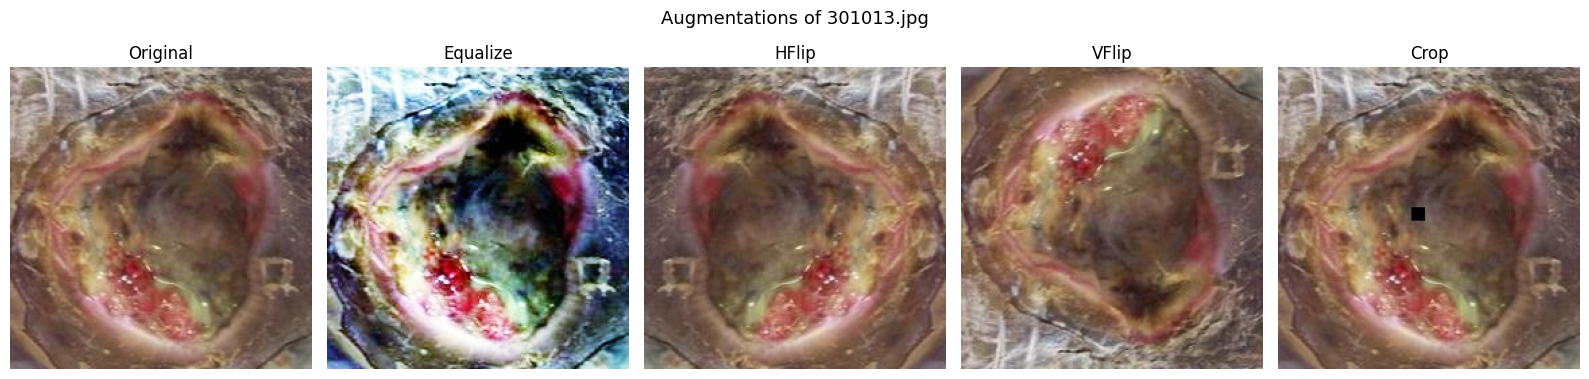

In [18]:
# ── Cell 6 (optional) : Quick visual check ───────────────────────────────────
import matplotlib.pyplot as plt

# Pick one minority image for visual comparison
sample_row = minority_df.iloc[0]
stem       = Path(sample_row["image"]).stem
ext        = Path(sample_row["image"]).suffix

# 1 original + 4 augmentations
fig, axes = plt.subplots(1, 5, figsize=(16, 4))
axes[0].imshow(Image.open(IMG_DIR / sample_row["image"]))
axes[0].set_title("Original")
axes[0].axis("off")

for ax, (suffix, label) in zip(
    axes[1:],
    [("e", "Equalize"), ("h", "HFlip"), ("v", "VFlip"), ("k", "Crop")]
):
    p = IMG_DIR / f"{stem}{suffix}{ext}"
    if p.exists():
        ax.imshow(Image.open(p))
        ax.set_title(label)
    else:
        ax.set_title(f"{label}\n(not found)")
    ax.axis("off")

plt.suptitle(f"Augmentations of {sample_row['image']}", fontsize=13)
plt.tight_layout()
plt.show()
